# Cosmic Integration: From BBH Mergers to Stellar Mergers

This notebook is a tutorial on how to use the cosmic integration post processing tools. This `cosmic_integration` module convolves our evolved binary stellar populations with star formation rate histories, specifically metallicity-specific star formation rate histories, which can take say our population of binary black holes (BBHs) and convert it into a predicted merger rate as a function of redshift (this module can also compute a detection rate observable by LIGO/Virgo as a function).

When `COMPAS` evolves a population of binary stars, it outputs and logs the final states of the binaries, whether they become double compact objects (DCOs, e.g. BBH, BHNS, BNS) or stellar mergers. Remember, our simulation outputs are at fixed metallicities (we evolve a population with the same birth metallicity in each simulation).

However, astrophysically, we need to consider star formation history, the rate of star formation at different ages of our universe. To put our `COMPAS` outputs in an astrophysical context we convolve them with the metallicity-specific star formation rate density, SFRD($Z_i, z$), which is a function of metallicity, $Z$, and redshift, $z$.

For example, the DCO merger rate measured by a comoving observer in the source frame of the merger at a given merger time $t_m$ (since the Big Bang) is given by:
$$R_m(t_m, M_1, M_2) = \frac{d^4 N_\text{merger}}{dt_m dV_c dM_1 dM_2}(t_m, M_1, M_2)$$
$$= \int dZ_i \int^{t_m}_0 dt_\text{delay} \text{SFRD}(Z_i, z(t_\text{form}=t_m-t_\text{delay})) \times \frac{d^4 N_\text{form}}{d M_\text{SFR} dt_\text{delay} dM_1 dM_2} (Z_i, t_\text{delay}, M_1, M_2)$$
This essentially calculates weighs each binary by the star-formation rate at that redshift and metallicity (aka "at what redshift would this binary have formed if it merges at redshift $z$?"). This equation is more complicated because we have to acount for the fact that DCO mergers have variable delay times (times between when the binary becomes a DCO and when it merges and emits a detectable gravitational wave signal).

For stellar mergers are expression becomes more simple because $t_\text{form}=t_\text{merge}$ and we do not care about binning by mass (that is important for LIGO observations):
$$R_m(t_m) = \frac{d^2N_\text{stellar merger}}{dt_m dV_c} (z_\text{merge})=\int dZ_i \text{SFRD}(Z_i, z_\text{merge}) \times \frac{dN_\text{stellar merger}}{dM_\text{SFR}}(Z_i)$$
We calculate the stellar merger rate by weighting each binary by the star-formation rate at the same redshift as the merger. 
- $R_m(t_m)$ - stellar merger rate per unit comoving volume per unit time, as a function of cosmic time $t_m$/$z_m$
- $\frac{d^2N_\text{stellar merger}}{dt_m dV_c} (z_\text{merge})$ - the number of stellar mergers per unit time per unit comoving volume at time $t_m$
- $Z_i$ - metallicity of the star-forming gas, integrated over because stars can form with differnt birth metallicites at different redshifts
- $\text{SFRD}(Z_i, z_\text{merge})$ - metallicity-specific star formation rate density, aka how much amss is being converted into stars per unit time per unit comoving volume at metallicity $Z_i$ and redshift $z(t_m)$
- $\frac{dN_\text{stellar merger}}{dM_\text{SFR}}(Z_i)$ - the stellar merger yield, how many stellar mergers are formed per solar mass of star formation at metallicity $Z_i$ (our COMPAS results, the count of merging systems divided by the total stellar mass evolved at that metallicity).

In this tutorial I will walk through the `cosmic_integration` module and how its used to calculate a merger rate for BBH mergers... it will be your task to modify the code to do this for stellar mergers!

## Build a Population

In `compas_python_utils/cosmic_integration` there is both a `FastCosmicIntegration.py` file and a `binned_cosmic_integrator` folder. `FastCosmicIntegration.py` is the old version of this post-processing algorithm. Let's focus on `binned_cosmic_integrator`.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import corner

from compas_python_utils.cosmic_integration.binned_cosmic_integrator.binary_population import (
    BinaryPopulation,
    generate_mock_population,
)
from compas_python_utils.cosmic_integration.binned_cosmic_integrator.cosmological_model import CosmologicalModel
from compas_python_utils.cosmic_integration.binned_cosmic_integrator.snr_grid import SNRGrid
from compas_python_utils.cosmic_integration.binned_cosmic_integrator.detection_matrix import (
    DetectionMatrix,
    compute_binned_detection_rates,
)

import os
os.environ['COMPAS_ROOT_DIR'] = '/home/cal/analam/Documents/COMPAS'

I created a new config file with key changes:
- `metallicity-distribution = "LOGUNIFORM"`: a log uniform distribution of metallicities, this randomly samples a log uniform distribution of metallicities from 0.001 to 0.03
- `number-of-systems=100000`: I want a large enough population so I generate a significant population of BBHs (BBHs are a rare final endpoint)
- `quiet=True`: I don't want to print out 100,000 lines (for each binary) or else my notebook will crash
- `output-container="COMPAS_Output_cosmic_integration`: I had to modify the original COMPAS code (`runSubmit.py`) to get this working (you can ask me about this) but I wanted to specify the folder to put the simulation output in

In [5]:
!compas_run_submit compas_cosmic_integration_config.yaml

python_version = 3
compas_executable_override /home/cal/analam/Documents/COMPAS/src/COMPAS
grid_filename None
/home/cal/analam/Documents/COMPAS/src/COMPAS --detailed-output False --quiet  --number-of-systems 100000 --metallicity-min 0.0001 --metallicity-max 0.03 --random-seed 42 --mass-transfer-fa 0.5 --common-envelope-alpha 1.0 --mode BSE --output-container COMPAS_Output_cosmic_integration --metallicity-distribution LOGUNIFORM --logfile-type HDF5 --output-path /home/cal/analam/Documents/stellar_mergers/tutorial

COMPAS v03.27.03 (gsl v2.7.1, boost v1.83.0, HDF5 v1.10.10)
Compact Object Mergers: Population Astrophysics and Statistics
by Team COMPAS (http://compas.science/index.html)
A binary star simulator

Go to https://compas.readthedocs.io/en/latest/index.html for the online documentation
Check https://compas.readthedocs.io/en/latest/pages/whats-new.html to see what's new in the latest release

Start generating binaries at Fri Apr 10 13:12:44 2026


Generated 100000 of 100000 binari

In [39]:
def load_compas_group(h5_path, group_name):
    """
    Load a COMPAS HDF5 output group into a dictionary.
    
    Parameters:
    -----------
    h5_path : str
        Path to COMPAS_Output.h5
    group_name : str
        Name of the HDF5 group (e.g., 'BSE_System_Parameters')
    
    Returns:
    --------
    data : dict
        Dictionary mapping column names to numpy arrays
    """
    data = {}
    with h5py.File(h5_path, 'r') as f:
        group = f[group_name]
        for col in group.keys():
            data[col] = group[col][:]
    return data

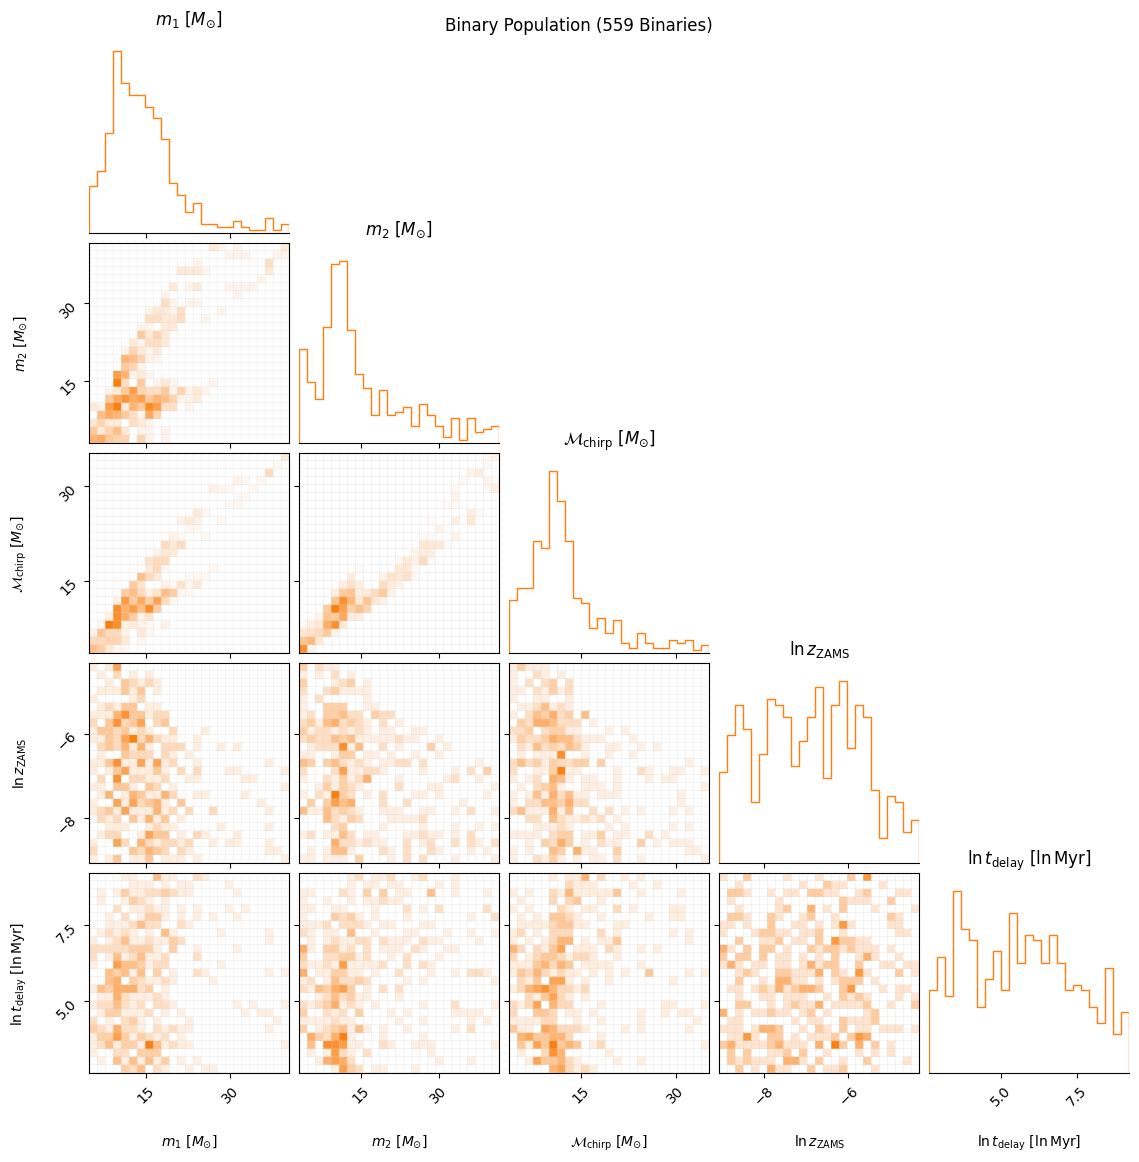

In [9]:
compas_filename = "COMPAS_Output_cosmic_integration/COMPAS_Output.h5"


mass_params = dict(m1_min=5, m1_max=150, m2_min=0.1)

bbh_population = BinaryPopulation.from_compas_h5(
    compas_filename,
    dcos_included=['BBH'],
    **mass_params,
    )

fig = bbh_population.plot()
plt.show()

This is a cool built in plot function to visualize the properties of the BBH population! Ok now onto the rates across comis history.

## Build a Cosmological Model

`CosmologicalModel` encodes the metallicity-specific star formation rate density $\text{SFRD}(Z_i, z)$. It is the product of two pieces:
$$\text{SFRD}(Z_i, z) = \underbrace{\frac{d^2 M_\text{SFR}}{dt_s \, dV_c}(z)}_{\text{total SFRD}} \times \underbrace{\frac{dP}{dZ_i}(z)}_{\text{metallicity PDF}}$$

The **total SFRD** uses a Madau-style parameterisation (Neijssel et al. 2019 preferred model by default). The **metallicity PDF** is a log-normal distribution whose mean metallicity evolves with redshift. Both are evaluated at the *formation* redshift for each binary.

Here we will build it. **They parameters are calibrated to the LIGO O1+O2 observations (Neijssel et al. 2019).**

In [10]:
cosmological_model = CosmologicalModel(
    # Star formation rate density parameters (Neijssel+19 preferred)
    aSF=0.01,   # normalisation [M_sun yr^-1 Mpc^-3]
    bSF=2.77,   # low-z slope
    cSF=2.90,   # turnover redshift
    dSF=4.70,   # high-z slope

    # Metallicity distribution parameters
    mu_0=0.035,   # mean metallicity at z=0
    sigma_0=0.39, # log-width at z=0
    mu_z=-0.23,   # redshift evolution of mean metallicity
    sigma_z=0,    # redshift evolution of width (0 = no evolution)
    alpha=0,      # skewness (0 = symmetric log-normal)

    # Metallicity integration limits (log10 scale)
    min_observed_log_metallicity=-4,
    max_observed_log_metallicity=0,
)

print(cosmological_model)

CosmologicalModel(a=0.010 b=2.770 c=2.900 d=4.700, N_0(0.035, 0.390);N_z(-0.230, 0.000))


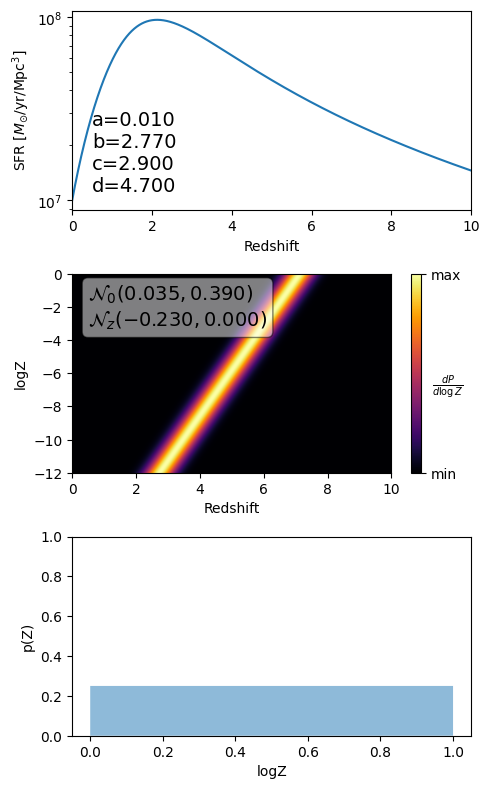

In [11]:
fig = cosmological_model.plot()
plt.show()

So in the top panel you see the total star formation rate density as a function of redshift. As you can see it peaks around $z\approx 2$. The middle panel shows the metallicity probability distribution at different redshifts. The bottom panel is the metallicity probability distribution for different $Z$ values.

## Run Cosmic Integration
With `compute_binned_detection_rates` we can loop over every BBH in our population. For each binary at each merger redshift bin it steps back by the delay time to find the formation redshift (formation of the BBH), looks at the SFRD at that formation redshift and metallicity, weights the binary's contribution to the merger rate by that SFRD value.

The result we get is a 2D matrix of rates binned in chirp mass and redshift. To get the merger rate as a function of redshift we just sum over all chirp mass bins.

In [12]:
snr_grid = SNRGrid(sensitivity="O3") # we will compute detection rates too but ignore them because we 
# only care about the intrinsic merger rate density in this tutorial

rate_matrix = compute_binned_detection_rates(
    bbh_population,
    cosmological_model,
    snr_grid,
    chirp_mass_bins=np.linspace(3, 40, 20),
    redshift_bins=np.linspace(0, 1, 20),
)

print("Rate matrix shape (chirp mass bins × redshift bins):", rate_matrix.shape)

Computing detection rates: 100%|██████████| 559/559 [00:00<00:00, 10694.44it/s]

Rate matrix shape (chirp mass bins × redshift bins): (20, 20)


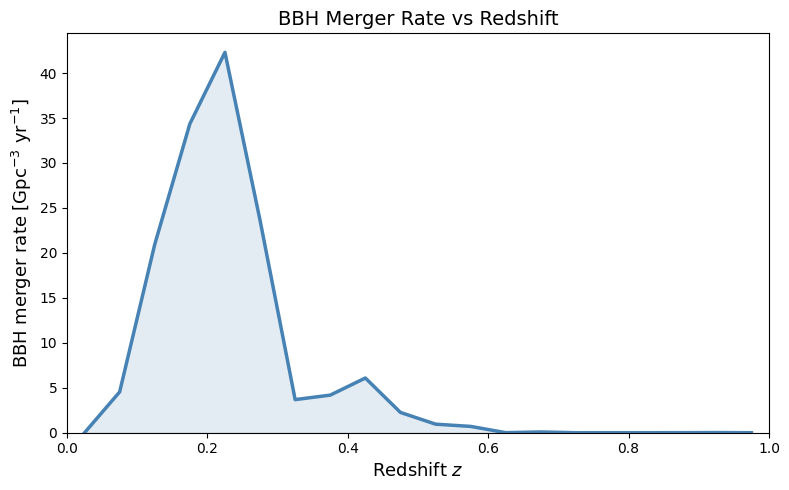

Peak merger rate at z = 0.23
Merger rate at z=0: 0.0 Gpc^-3 yr^-1


In [17]:
redshift_bins = np.linspace(0, 1, 21)
z_centres = 0.5 * (redshift_bins[:-1] + redshift_bins[1:])

# Sum over all chirp mass bins to get total rate per redshift bin
merger_rate_vs_z = rate_matrix.sum(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(z_centres, merger_rate_vs_z, lw=2.5, color='steelblue')
ax.fill_between(z_centres, 0, merger_rate_vs_z, alpha=0.15, color='steelblue')

ax.set_xlabel('Redshift $z$', fontsize=13)
ax.set_ylabel(r'BBH merger rate [Gpc$^{-3}$ yr$^{-1}$]', fontsize=13)
ax.set_title('BBH Merger Rate vs Redshift', fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print(f"Peak merger rate at z = {z_centres[merger_rate_vs_z.argmax()]:.2f}")
print(f"Merger rate at z=0: {merger_rate_vs_z[0]:.1f} Gpc^-3 yr^-1")

Ok obviously this isn't the nicest looking curve but we are working with only $\approx 200$ BBHs, we are dominanted by small number noise.